# CNOT baseline

This notebook loads the results from ft mode and trel mode from Ethan Lake's code for quantum memory local decoder.

### ft mode

In [9]:
%load_ext autoreload
%autoreload 2

# Full fault-tolerance scan
from analysis_utils import load_ft_scan

baseline_scan = load_ft_scan(
    "../results/baseline/ft/full_scan",
    p_values=[0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.020],
    L_values=[5, 7, 9, 13, 19],
    expected_repeats=5,
    result_pattern="2d_Ft*.txt",
    success_field="Ft",
    scan_label="Ft",
)
baseline_scan.print_summary()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 250 requested Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]]


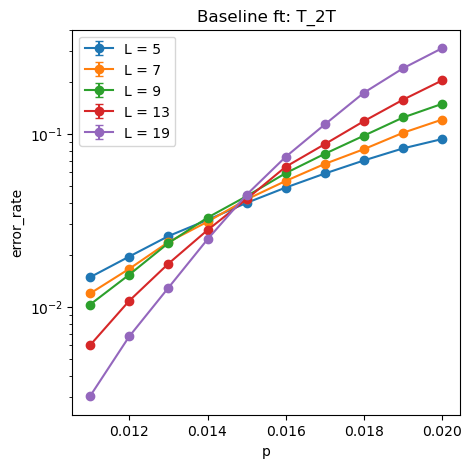

#### Finite-size scaling fit: Baseline ft

Degree-2 model: $P_L(p)=A+Bx+Cx^{2}$, with $x=(p-p_c)L^{1/\nu}$. The fit uses $p \in [0.011, 0.020]$ and $L \in [5, 7, 9, 13, 19]$.

| Quantity | Fit result |
|---|---:|
| $p_c$ | 0.01432(2) |
| $p_c$ (%) | 1.432(2) |
| $\nu$ | 1.35(1) |
| $A$ | 0.0360(2) |
| $B$ | 2.31(3) |
| $C$ | 41(1) |
| $\chi^2 / \mathrm{dof}$ | 2012.77 / 45 = 44.73 |
| goodness-of-fit $p$-value | 0 |

> **Fit-quality warning:** the degree-2 scaling model is rejected at the 5% level for this window. The covariance errors are statistical only; vary the degree, fit window, and minimum $L$ before quoting a final uncertainty.

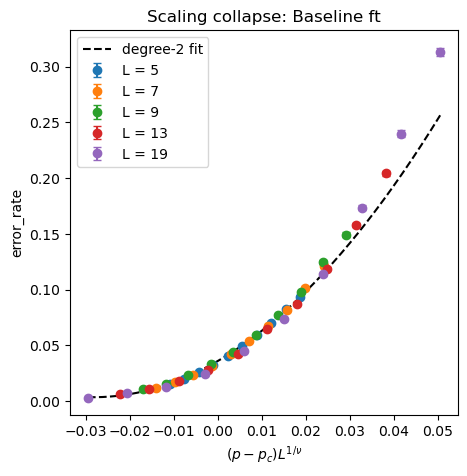

## Baseline fit summary

| Timing and block | degree | $p_c$ | $p_c$ (%) | $\nu$ | $\chi^2 / \mathrm{dof}$ | fit $p$-value |
|---|---:|---:|---:|---:|---:|---:|
| Baseline ft | 2 | 0.01432(2) | 1.432(2) | 1.35(1) | 44.73 | 0 |

In [10]:
from analysis_utils import (
    display_finite_size_scaling_fit,
    display_fit_summary,
    fit_finite_size_scaling,
    plot_rate_scan,
)

# Change this positive integer to adjust the scaling-polynomial degree.
fit_degree = 2

plot_rate_scan(
    baseline_scan,
    title="Baseline ft: T_2T",
    ylabel="error_rate",
)

fit_baseline = fit_finite_size_scaling(
    baseline_scan,
    label="Baseline ft",
    polynomial_degree=fit_degree,
)
display_finite_size_scaling_fit(fit_baseline, "error_rate")
display_fit_summary([fit_baseline], title="Baseline fit summary")


### trel mode

In [11]:
from analysis_utils import load_trel_scan

# Use the aggregate files here; repeat_* folders contain the raw repeat inputs.
baseline_trel_scan = load_trel_scan(
    "../results/baseline/trel/full_scan",
    p_values=[0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.020],
    L_values=[5, 7, 9, 13, 19],
)
baseline_trel_scan.print_summary()


Loaded 50 requested trel files; ignored 0 files outside the requested lists
trel L values: [ 5  7  9 13 19]
trel p values: [0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
trel sample counts:
 [[1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
 [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
 [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
 [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
 [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]]


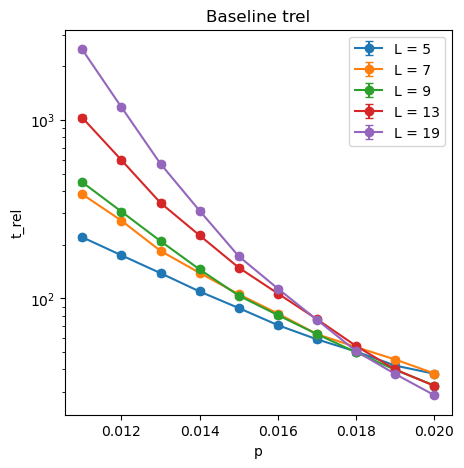

In [12]:
from analysis_utils import plot_trel_scan

plot_trel_scan(baseline_trel_scan)
